In [1]:
from d2M_function import RCWAForward, TinyDNet, compute_Iout_vectorized
import torch, torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from Model3 import IoutCNNMLP
import hdf5storage
from mpl_toolkits.axes_grid1 import make_axes_locatable
import torch.nn.functional as F
import time
from compute_grid_parameters import compute_grid_parameters

In [2]:
def show_triptych(I_out_real, I_out_pred, *, cmap_res='magma',
                  cbar_size='3%', cbar_pad=0.05):
    """并排画 I_real / I_pred / |residual|，每个子图右侧加等高瘦色条。"""
    I_r = I_out_real.detach().cpu().squeeze().numpy()
    I_p = I_out_pred.detach().cpu().squeeze().numpy()
    res = np.abs(I_r - I_p)

    # 统一颜色范围（不然两个图看起来不对等）
    vmin = min(I_r.min(), I_p.min())
    vmax = max(I_r.max(), I_p.max())

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    axes[0].set_title('I_out real')
    axes[1].set_title('I_out pred')
    axes[2].set_title('residual')

    ims = []
    ims.append(axes[0].imshow(I_r))
    ims.append(axes[1].imshow(I_p))
    ims.append(axes[2].imshow(res))

    for ax, im in zip(axes, ims):
        ax.set_axis_off()
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=cbar_size, pad=cbar_pad)
        fig.colorbar(im, cax=cax)

    plt.show()

In [3]:
M_path = r"F:\科研项目\XueXinyuan\2025_I2parameters\dataset\Simu\M_Decoder.mat"
M_dict = hdf5storage.loadmat(M_path)
M_Decoder = M_dict["M"]
M_Decoder = torch.from_numpy(M_Decoder)
print(M_Decoder.shape)
M_Decoder = M_Decoder.permute(0, 1, 3, 2)
M_Decoder = M_Decoder.reshape(256, 256, 4*121)
print(M_Decoder.shape)

Sencoder_path = r"F:\科研项目\XueXinyuan\2025_I2parameters\dataset\Simu\S_Encoder.mat"
Sencoder_dict = hdf5storage.loadmat(Sencoder_path)
S_Encoder = Sencoder_dict["S"] 
S_Encoder = torch.from_numpy(S_Encoder)
print(S_Encoder.shape)
S_Encoder = S_Encoder.unsqueeze(4).unsqueeze(0)
print(S_Encoder.shape)

Spec_path = r"F:\科研项目\XueXinyuan\2025_I2parameters\dataset\Simu\spec.mat"
Spec_dict = hdf5storage.loadmat(Spec_path)
Spec = Spec_dict["spec"]
Spec = np.array(Spec, dtype=np.float64)
Spec = torch.from_numpy(Spec)
# Spec = Spec[:, 15:136]
print(Spec.shape)

torch.Size([256, 256, 121, 4])
torch.Size([256, 256, 484])
torch.Size([256, 256, 121, 4])
torch.Size([1, 256, 256, 121, 4, 1])
torch.Size([1, 484])


# run

training runtime: 9 min 19 s
0.5120019912719727


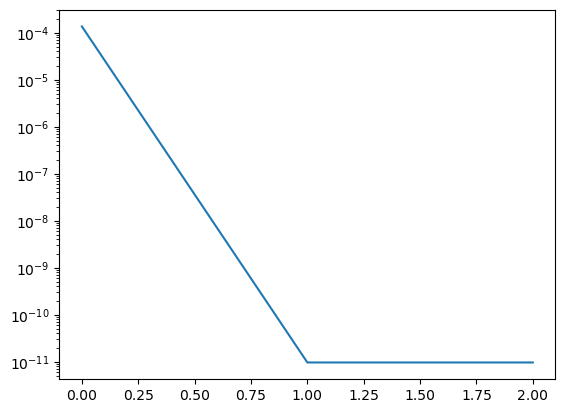

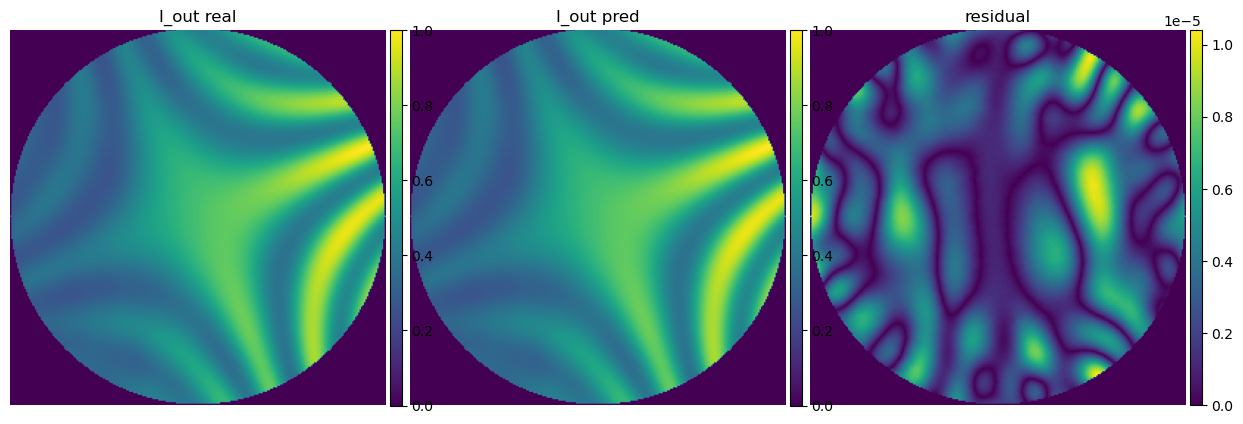

label lamda:0.512
predicted lamda:0.5120019912719727


In [5]:
device = "cuda"
rcwa = RCWAForward(
    air_path=r"F:\科研项目\XueXinyuan\2025_I2parameters\光栅\material_lambda_nk\Air_lambda_n_k.mat",
    si_path=r"F:\科研项目\XueXinyuan\2025_I2parameters\光栅\material_lambda_nk\Si_lambda_n_k.mat",
    theta_deg=55.0, phi_deg=0.0,
    device=device, dtype=None  # 自动：cuda→float32, cpu→float64
)
thickness_label, Lambda_label, duty_cycle_label = 0.472, 0.512, 0.4375
ms_label = rcwa(thickness_label, Lambda_label, duty_cycle_label)  # -> [W,16,T]
ms_label = ms_label.reshape(121, 4, 4)
I_out_real = compute_Iout_vectorized(ms_label, S_Encoder, Spec, M_Decoder, eps=1e-12)

######################################################################################################################################

start = time.perf_counter()


training_loss, predicted_lamda = compute_grid_parameters(0.1, 1.0, 20, 
                                                         thickness_label, duty_cycle_label,
                                                         rcwa, S_Encoder, Spec, M_Decoder, I_out_real, device)
elapsed = int(time.perf_counter() - start)
m, s = divmod(elapsed, 60)
print(f"training runtime: {m} min {s} s")

print(predicted_lamda)

######################################################################################################################################

plt.figure()
plt.plot(training_loss)
plt.yscale("log")
plt.show()

ms_pred = rcwa(thickness_label, predicted_lamda, duty_cycle_label)  # [W,16] 或 [W,16,T]
ms_pred = ms_pred.reshape(121, 4, 4)
I_out_pred = compute_Iout_vectorized(ms_pred, S_Encoder, Spec, M_Decoder, eps=1e-12)
show_triptych(I_out_real, I_out_pred)

print(f"label lamda:{Lambda_label}")
print(f"predicted lamda:{predicted_lamda}")